# 패키지 import

In [1]:
### 필요 패키지 import ###
from __future__ import absolute_import
from __future__ import division
from __future__ import print_function

import numpy as np
import pandas as pd
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import os
from tqdm import tqdm, notebook

In [2]:
import torch
from torch.utils.data import DataLoader, Dataset
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

print(torch.__version__)

1.10.1


# Data Load

In [3]:
seed = 7

classes_names = ["포트홀 없음", "포트홀", "보수 완료된 포트홀"]
train_data = pd.read_csv("Train_datasets_labels.csv")
valid_data = pd.read_csv("Validation_datasets_labels.csv")


train_data = train_data.sample(frac=1, random_state=seed).reset_index(drop=True)
valid_data = valid_data.sample(frac=1, random_state=seed).reset_index(drop=True)

print(len(train_data))
print(len(valid_data))

23389
300


Label : 포트홀


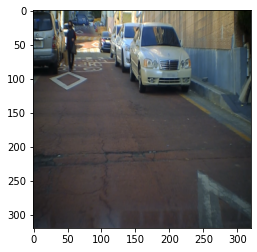

In [4]:
# Train
idx = 15910

print("Label :", classes_names[train_data.iloc[idx, 1]])

img = Image.open(train_data.iloc[idx,0])
plt.imshow(img)

Label : 포트홀


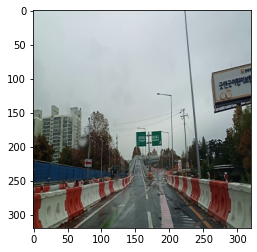

In [5]:
# Valid
idx = 261

print("Label :", classes_names[valid_data.iloc[idx, 1]])

img = Image.open(valid_data.iloc[idx,0])
plt.imshow(img)

# Define Data-Sets

In [6]:
class MyDataset(Dataset):
    def __init__(self, df):
        self.df = df
        self.x=0; self.y=0
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        file_path = self.df.iloc[idx][0]
        img = np.array(PIL.Image.open(train_data.iloc[idx][0])) / 255.
        label = torch.tensor(train_data.iloc[idx][1])
        
        self.x = np.transpose(torch.tensor(img).float(), (2,0,1))
        self.y = F.one_hot(label, num_classes=3).float()
        
        return self.x, self.y
    
train = MyDataset(train_data)
train_loader = DataLoader(train, batch_size = 32)
valid = MyDataset(valid_data)
valid_loader = DataLoader(valid, batch_size = 32)

In [7]:
xx ,yy = train.__getitem__(0)
print(xx.shape)
print(yy.shape)

torch.Size([3, 320, 320])
torch.Size([3])


# Define Train,Valid Function

In [8]:
loss_fn = nn.CrossEntropyLoss()

def calc_acc(X, Y):
    x_val, x_idx = torch.max(X, dim=1)
    y_val, y_idx = torch.max(Y, dim=1)
    return (x_idx == y_idx).sum().item()

def train(EPOCHS, model, train_loader, opt):
    for epoch in range(1, EPOCHS+1):
        model.train()
        train_acc = 0
        print("### EPOCH {} ###".format(epoch))
        for batch_idx, (img,label) in enumerate(notebook.tqdm(train_loader)):
            img, label = img.to(DEVICE), label.to(DEVICE)
            
            output = model(img)
            loss = loss_fn(output, label)
            
            opt.zero_grad()
            loss.backward()
            opt.step()
            
            train_acc += calc_acc(output, label)
            if batch_idx % 100 == 0 and batch_idx != 0:
                print("Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}\t Acc : {:.3f}".format(
                    epoch, 
                    batch_idx * len(img), 
                    len(train_loader.dataset), 
                    100. * batch_idx / len(train_loader), 
                    loss.item(),
                    train_acc / len(train_loader.dataset)))
        t_loss, t_acc = evaluate(model, valid_loader)
        print("[{}] Test Loss: {:.4f}\t accuracy: {:.2f}%\n".format(epoch, t_loss, t_acc))
                
def evaluate(model, valid_loader):
    model.eval()
    t_loss = 0
    correct = 0
    
    with torch.no_grad():
        for img, label in notebook.tqdm(valid_loader):
            img, label = img.to(DEVICE), label.to(DEVICE)
            
            output = model(img)
            t_loss += loss_fn(output, label)
            
#             print(output.shape)
#             print(label.shape)
            correct += calc_acc(output, label)
    
#     print(torch.max(output, dim=1)[1])
#     print(torch.max(label, dim=1)[1])
    t_loss /= len(valid_loader)
    t_acc = 100. * correct / len(valid_loader.dataset)
    return t_loss, t_acc

# Define Model

In [9]:
USE_CUDA = torch.cuda.is_available()
DEVICE = torch.device("cuda" if USE_CUDA else "cpu")

print(USE_CUDA)
print(DEVICE)

True
cuda


In [16]:
class Model1(nn.Module):
    def __init__(self):
        super(Model1, self).__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 8, kernel_size = 3, padding = 1)
        self.conv2 = nn.Conv2d(in_channels = 8, out_channels = 16, kernel_size = 3, padding = 1)
        self.conv3 = nn.Conv2d(in_channels = 16, out_channels = 32, kernel_size = 3, padding = 1)
        self.conv4 = nn.Conv2d(in_channels = 32, out_channels = 64, kernel_size = 3, padding = 1)
        self.pool = nn.MaxPool2d(kernel_size = 2, stride = 2)
        self.fc1 = nn.Linear(20 * 20 * 64, 1024)
        self.fc2 = nn.Linear(1024, 64)
        self.fc3 = nn.Linear(64, 3)
        
        self.conv1_bn = nn.BatchNorm2d(8)
        self.conv2_bn = nn.BatchNorm2d(16)
        self.conv3_bn = nn.BatchNorm2d(32)
        self.conv4_bn = nn.BatchNorm2d(64)
        
        self.act_fn = nn.ReLU()
        
        self.dropout_p = 0.2            # drop out 비율 값
        
    def forward(self, x):
        x = self.conv1(x) # 320 * 320 * 3 -> 320 * 320 * 8
        x = self.conv1_bn(x)
        x = self.act_fn(x)     # 320 * 320 * 8
        x = self.pool(x)  # 160 * 160 * 8
        
        x = self.conv2(x) # 160 * 160 * 8 -> 160 * 160 * 16
        x = self.conv2_bn(x)
        x = self.act_fn(x)     # 160 * 160 * 16
        x = self.pool(x)  # 80  *  80 * 16
        
        x = self.conv3(x) # 80 * 80 * 16 -> 80 * 80 * 32
        x = self.conv3_bn(x)
        x = self.act_fn(x)     # 80 * 80 * 32
        x = self.pool(x)  # 40 * 40 * 32
        
        x = self.conv4(x) # 40 * 40 * 32 -> 40* 40 * 64
        x = self.conv4_bn(x)
        x = self.act_fn(x)     # 40 * 40 * 64
        x = self.pool(x)  # 20 * 20 * 64
        
        x = x.contiguous().view(-1, 20*20*64)
        x = self.fc1(x)
#         x = F.dropout(x, p = self.dropout_p) # Drop out 적용
        x = self.act_fn(x)
        x = self.fc2(x)
#         x = F.dropout(x, p = self.dropout_p) # Drop out 적용
        x = self.act_fn(x)
        x = self.fc3(x)
        x = F.log_softmax(x, dim=1)
        return x

In [17]:
model = Model1().to(DEVICE)

optimizer = optim.Adam(model.parameters())
print("DEVICE: ", DEVICE)
print("MODEL: ", model)

DEVICE:  cuda
MODEL:  Model1(
  (conv1): Conv2d(3, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=25600, out_features=1024, bias=True)
  (fc2): Linear(in_features=1024, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=3, bias=True)
  (conv1_bn): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2_bn): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3_bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (act_fn): ReLU()


In [18]:
train(15, model, train_loader, optimizer)

### EPOCH 1 ###


  0%|          | 0/731 [00:00<?, ?it/s]

Train Epoch: 1 [3200/23389 (14%)]	Loss: 0.926192	 Acc : 0.080
Train Epoch: 1 [6400/23389 (27%)]	Loss: 0.616128	 Acc : 0.168
Train Epoch: 1 [9600/23389 (41%)]	Loss: 0.572510	 Acc : 0.263
Train Epoch: 1 [12800/23389 (55%)]	Loss: 0.569959	 Acc : 0.357
Train Epoch: 1 [16000/23389 (68%)]	Loss: 0.577216	 Acc : 0.454
Train Epoch: 1 [19200/23389 (82%)]	Loss: 0.641533	 Acc : 0.553
Train Epoch: 1 [22400/23389 (96%)]	Loss: 0.485336	 Acc : 0.650


  0%|          | 0/10 [00:00<?, ?it/s]

[1] Test Loss: 0.5878	 accuracy: 72.00%

### EPOCH 2 ###


...

[14] Test Loss: 0.0725	 accuracy: 98.33%

### EPOCH 15 ###


  0%|          | 0/731 [00:00<?, ?it/s]

Train Epoch: 15 [3200/23389 (14%)]	Loss: 0.009107	 Acc : 0.135
Train Epoch: 15 [6400/23389 (27%)]	Loss: 0.096603	 Acc : 0.270
Train Epoch: 15 [9600/23389 (41%)]	Loss: 0.054115	 Acc : 0.405
Train Epoch: 15 [12800/23389 (55%)]	Loss: 0.048669	 Acc : 0.540
Train Epoch: 15 [16000/23389 (68%)]	Loss: 0.006273	 Acc : 0.676
Train Epoch: 15 [19200/23389 (82%)]	Loss: 0.005803	 Acc : 0.811
Train Epoch: 15 [22400/23389 (96%)]	Loss: 0.048784	 Acc : 0.946


  0%|          | 0/10 [00:00<?, ?it/s]

[15] Test Loss: 0.0663	 accuracy: 97.00%



In [19]:
result = evaluate(model, valid_loader)
print("Loss : {:.4f}\t acc : {:.2f}".format(result[0], result[1]))

  0%|          | 0/10 [00:00<?, ?it/s]

Loss : 0.0663	 acc : 97.00
